<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/test_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook explains processing NeuroPAL 3D images using the Cellpose package on Google Colab using the GPU.

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

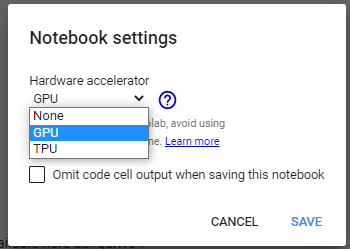

### Install Cellpose-SAM

In [ ]:
# !pip install git+https://www.github.com/mouseland/cellpose.git

Check GPU and instantiate model - will download weights.

In [1]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from cellpose import utils, io

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2026-04-21 04:06:01,451 [INFO] WRITING LOG OUTPUT TO /home/anshitagupta_umass_edu/.cellpose/run.log
2026-04-21 04:06:01,452 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-21 04:06:02,044 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 04:06:02,045 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 04:06:02,046 [INFO] >>>> using GPU (CUDA)
2026-04-21 04:06:04,139 [INFO] >>>> loading model /home/anshitagupta_umass_edu/.cellpose/models/cpsam


### Download example images

In [ ]:
from ..scripts.utils import load_raw_data, load_clean_data

RAW_DATA = False # Can be True or False
dataset = "000981" # Can be 000981 or 000715
csv_col_suffix = "_aniso" # Can be "_aniso" or "_iso"

In [3]:
if RAW_DATA:
    test_data, img_data = load_raw_data(dataset, sample_size=1)
else:
    test_data, img_data = load_clean_data(dataset, csv_col_suffix, sample_size=1)


[000981] sub-20220427-h2
  Datatype:       float32
  Shape:          (1024, 900, 23, 3)
  Min:            0.0, Max: 255.0
  Mean:           0.2084
  Std Dev:        4.7270
  Median:         0.0000
  Size (MB):      254.36 MB
  Num Elements:   63590400
  Ndim:           4


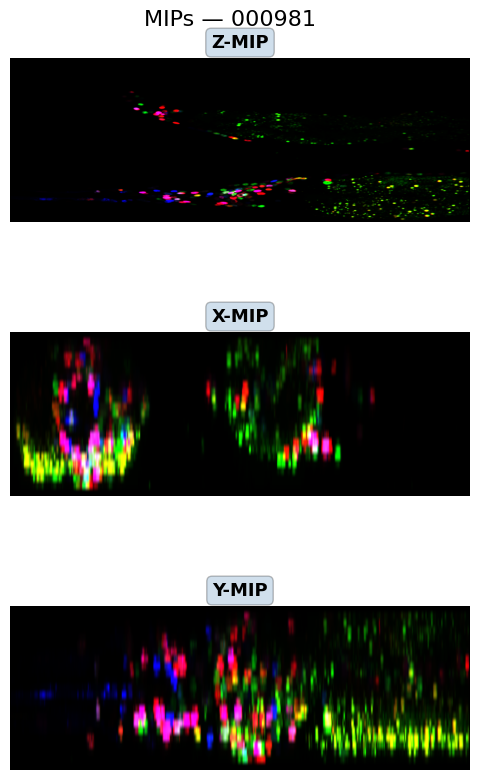

In [ ]:
from ..scripts.utils_graphs import plot_3d_mip

plt = plot_3d_mip(img_data[0], dataset, figsize=(5, 8))
plt.show()

# Run Cellpose-SAM in 3D




There are two ways to run cellpose in 3D, this cell shows both, choose which one works best for you.

First way: computes flows from 2D slices and combines into 3D flows to create masks


In [5]:
masks, flows, _ = model.eval(
    img_data[0],
    z_axis=2,          
    channel_axis=3,   
    do_3D=True,
    flow3D_smooth=1,
    batch_size=32,
)

2026-04-21 04:06:17,592 [INFO] running YX: 23 planes of size (1024, 900)
2026-04-21 04:07:34,664 [INFO] 100%|##########| 23/23 [01:17<00:00,  3.35s/it]
2026-04-21 04:07:34,871 [INFO] running ZY: 1024 planes of size (23, 900)
2026-04-21 04:18:34,384 [INFO] 100%|##########| 171/171 [10:59<00:00,  3.86s/it]
2026-04-21 04:18:34,455 [INFO] running ZX: 900 planes of size (23, 1024)
2026-04-21 04:28:13,594 [INFO] 100%|##########| 150/150 [09:39<00:00,  3.86s/it]
2026-04-21 04:28:13,959 [INFO] network run in 1316.37s
2026-04-21 04:28:13,960 [INFO] smoothing flows with ZYX sigma=[1, 1, 1]
2026-04-21 04:28:15,999 [INFO] masks created in 0.83s


Second way: computes masks in 2D slices and stitches masks in 3D based on mask overlap

Note stitching (with stitch_threshold > 0) can also be used to track cells over time.

In [11]:
# 2. computes masks in 2D slices and stitches masks in 3D based on mask overlap
print('running cellpose 2D + stitching masks')
masks_stitched, flows_stitched, _ = model.eval(img_data[0], z_axis=2, channel_axis=3,
                                                  batch_size=32,
                                                  do_3D=False, stitch_threshold=0.5)

running cellpose 2D + stitching masks
2026-04-21 04:51:38,522 [INFO] 100%|##########| 23/23 [01:13<00:00,  3.20s/it]
2026-04-21 04:51:38,528 [INFO] network run in 73.67s
2026-04-21 04:51:38,529 [INFO] 0%|          | 0/23 [00:00<?, ?it/s]
2026-04-21 04:51:38,530 [INFO] No cell pixels found.
2026-04-21 04:51:39,698 [INFO] No cell pixels found.
2026-04-21 04:51:39,700 [INFO] 100%|##########| 23/23 [00:01<00:00, 19.64it/s]
2026-04-21 04:51:39,701 [INFO] stitching 23 planes using stitch_threshold=0.500 to make 3D masks


100%|██████████| 22/22 [00:00<00:00, 61.44it/s]


2026-04-21 04:51:40,206 [INFO] masks created in 1.68s


Results from 3D flows => masks computation

3D Merged Predictions — X: [448:576], Y: [161:289]


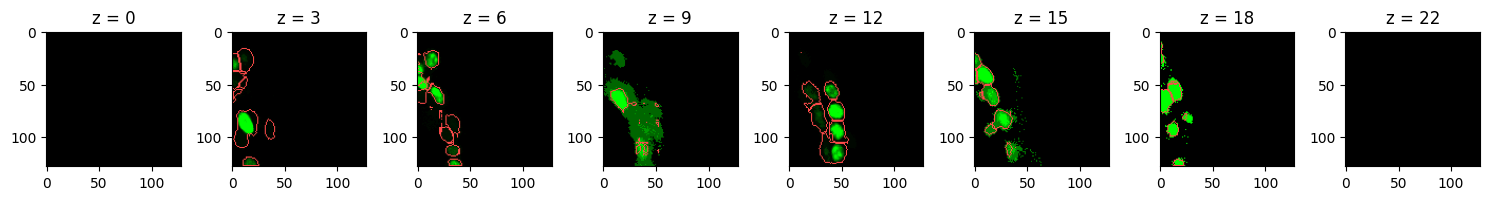

In [12]:
# DISPLAY RESULTS 3D flows => masks
n_z      = masks.shape[0]  # actual Z depth, don't hardcode 75
n_panels = 8
z_planes = np.linspace(0, n_z - 1, n_panels, dtype=int)  # evenly spaced Z slices

# crop image
crop_size = 128

cx = img_data[0].shape[0] // 2   
cy = img_data[0].shape[1] // 4 

x0 = max(0, cx - crop_size // 2)
x1 = min(img_data[0].shape[0], cx + crop_size // 2)
y0 = max(0, cy - crop_size // 2)
y1 = min(img_data[0].shape[1], cy + crop_size // 2)

print(f"3D Merged Predictions — X: [{x0}:{x1}], Y: [{y0}:{y1}]")

plt.figure(figsize=(15, 3))
for i, iplane in enumerate(z_planes):

    # ── Image slice
    img_slice = img_data[0][x0:x1, y0:y1 , iplane, [1, 0]].transpose(2, 0, 1)   # (2, X, Y)
    img0 = plot.image_to_rgb(img_slice.copy(), channels=[2,3])

    plt.subplot(1, n_panels, i + 1)

    # ── Mask slice
    mask_slice = masks[iplane, x0:x1, y0:y1]
    outlines = utils.masks_to_outlines(mask_slice)
    outX, outY = np.nonzero(outlines)
    imgout = img0.copy()
    imgout[outX, outY] = np.array([255, 75, 75])

    plt.imshow(imgout)
    plt.title(f'z = {iplane}')

plt.tight_layout()
plt.show()

Results from stitching

Stiched 3D Predictions — X: [448:576], Y: [161:289]


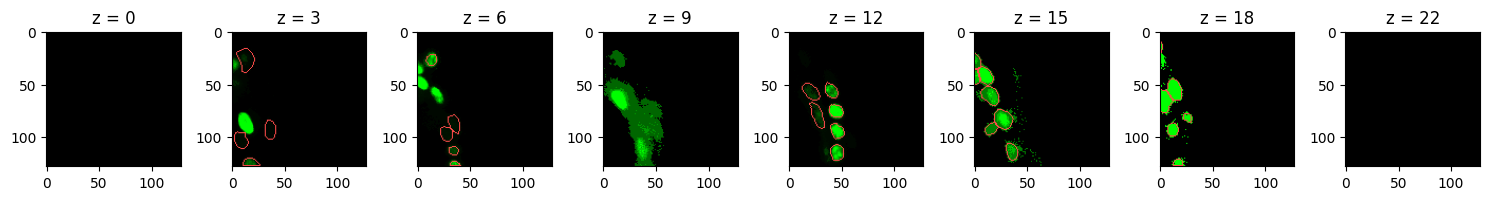

In [13]:
# DISPLAY RESULTS stitching
n_z      = masks.shape[0]  # actual Z depth, don't hardcode 75
n_panels = 8
z_planes = np.linspace(0, n_z - 1, n_panels, dtype=int)  # evenly spaced Z slices

# crop image
crop_size = 128

cx = img_data[0].shape[0] // 2
cy = img_data[0].shape[1] // 4

x0 = max(0, cx - crop_size // 2)
x1 = min(img_data[0].shape[0], cx + crop_size // 2)
y0 = max(0, cy - crop_size // 2)
y1 = min(img_data[0].shape[1], cy + crop_size // 2)

print(f"Stiched 3D Predictions — X: [{x0}:{x1}], Y: [{y0}:{y1}]")

plt.figure(figsize=(15, 3))
for i, iplane in enumerate(z_planes):

    # ── Image slice
    img_slice = img_data[0][x0:x1, y0:y1, iplane, [1, 0]].transpose(2, 0, 1)   # (2, X, Y)
    img0 = plot.image_to_rgb(img_slice.copy(), channels=[2,3])

    plt.subplot(1, n_panels, i + 1)

    # ── Mask slice
    mask_slice = masks_stitched[iplane, x0:x1, y0:y1]
    outlines = utils.masks_to_outlines(mask_slice)
    outX, outY = np.nonzero(outlines)
    imgout = img0.copy()
    imgout[outX, outY] = np.array([255, 75, 75])

    plt.imshow(imgout)
    plt.title(f'z = {iplane}')

plt.tight_layout()
plt.show()